In [6]:
import sys
from helpers import get_best_model_path, plot_patch_comparison
import os
import torch
import yaml
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    print(f"Pfad angepasst: Suche jetzt auch in {parent_dir}")
from ConvLSTM_model import ConvLSTM_Model
from dataset import ARCEME_Dataset, get_val_tiles_auto

## Get best model

In [7]:
best_ckpt = get_best_model_path(log_dir="../tb_logs")
print(f"Lade bestes Modell: {best_ckpt}")

Lade bestes Modell: ../tb_logs/run_2026-03-10_16-23-00/fold_2/version_0/checkpoints/best-model-epoch=02-val_loss=0.0007.ckpt


## Get config

In [8]:
os.path.dirname(best_ckpt)

'../tb_logs/run_2026-03-10_16-23-00/fold_2/version_0/checkpoints'

In [9]:
config_path = os.path.join(os.path.dirname(best_ckpt), "../hparams.yaml")
with open(config_path, "r") as f:
    cfg = yaml.safe_load(f)
cfg = cfg["cfg"] 
patch_size = cfg["data"]["patch_size"]
context_length = cfg["data"]["context_length"]
target_length = cfg["data"]["target_length"]
v_cfg = cfg["data"]["variables"]

## Initialize model

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == "cpu":
    model = ConvLSTM_Model.load_from_checkpoint(best_ckpt, map_location=device)
else:
    model = ConvLSTM_Model.load_from_checkpoint(best_ckpt)
    model.to(device) # schiebt modell zu gpu
model.eval()

ConvLSTM_Model(
  (model): ConvLSTM(
    (encoder_cells): ModuleList(
      (0): ConvLSTMCell(
        (conv): Conv2d(93, 256, kernel_size=(5, 5), stride=(1, 1), padding=same)
      )
      (1-2): 2 x ConvLSTMCell(
        (conv): Conv2d(128, 256, kernel_size=(5, 5), stride=(1, 1), padding=same)
      )
    )
    (decoder_cells): ModuleList(
      (0): ConvLSTMCell(
        (conv): Conv2d(86, 256, kernel_size=(5, 5), stride=(1, 1), padding=same)
      )
      (1-2): 2 x ConvLSTMCell(
        (conv): Conv2d(128, 256, kernel_size=(5, 5), stride=(1, 1), padding=same)
      )
    )
    (predict_layer): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
  )
  (mse_criterion): MaskedMSELoss()
  (l1_criterion): MaskedL1Loss()
)

## Get test data

In [18]:
# Define cubes
test_files = [
    # "/scratch/sloeblein/postprocessed/2018-0103-BWA_postprocessed.zarr",
    "/scratch/sloeblein/postprocessed/2020-0183-GTM_postprocessed.zarr",
   "/scratch/sloeblein/postprocessed/2020-0264-GTM_postprocessed.zarr"
]

# Configuration
N_CUBES_TO_LOAD = 1  
PATCHES_PER_CUBE = 4

# Select files
selected_files = test_files[:N_CUBES_TO_LOAD]

# Prepare tiles
all_possible_tiles = get_val_tiles_auto(
    selected_files, 
    patch_size=patch_size, 
    dim_max=1000
)
test_tiles = []
tiles_per_full_cube = len(all_possible_tiles) // len(selected_files)

for c_idx in range(len(selected_files)):
    # Start-Index für diesen Cube in der Liste
    start = c_idx * tiles_per_full_cube
    # Nimm nur die ersten PATCHES_PER_CUBE für diesen Cube
    test_tiles.extend(all_possible_tiles[start : start + PATCHES_PER_CUBE])

print(f"Test Tiles Länge: {len(test_tiles)}")

# Create dataset & loader
test_ds = ARCEME_Dataset(
    selected_files, 
    context_length = context_length,
    target_length = target_length,
    patch_size=patch_size, 
    train=False, 
    s2_vars=v_cfg["s2"],
    s1_vars=v_cfg["s1"],
    era5_vars=v_cfg["era5"],
    static_vars=v_cfg["static"],
    fixed_tiles=test_tiles
)

test_loader = torch.utils.data.DataLoader(
    test_ds, 
    batch_size=16,       
    shuffle=False,      
    num_workers=0,
    pin_memory=False,       
)
print(f"Setup fertig: {len(selected_files)} Cubes mit insgesamt {len(test_ds)} Patches.")

Validation Strategy: Created 16 tiles per cube.
Grid: 4x4 patches, Stride: 248, Total Tiles: 16
Test Tiles Länge: 4
Setup fertig: 1 Cubes mit insgesamt 4 Patches.



🌍 EVALUIERE CUBE: 2020-0183-GTM_postprocessed.zarr

--- 🧩 Patch 1/4 (y=0, x=0) ---
Step       | MSE          | Valid Pixels    | % of Patch
-------------------------------------------------------
Timestep 1  | 0.000519     | 62585           |   95.5%
Timestep 2  | 0.000000     | 0               |    0.0%
Timestep 3  | 0.020975     | 63810           |   97.4%
Timestep 4  | 0.041911     | 53138           |   81.1%
Timestep 5  | 0.000000     | 0               |    0.0%
  [Patch 1/4] Koordinaten: y=0, x=0 | Avg MSE: 0.012681


/net/home/sloeblein/ARCEME-Vegetation-Recovery/model/visual_analysis/helpers.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


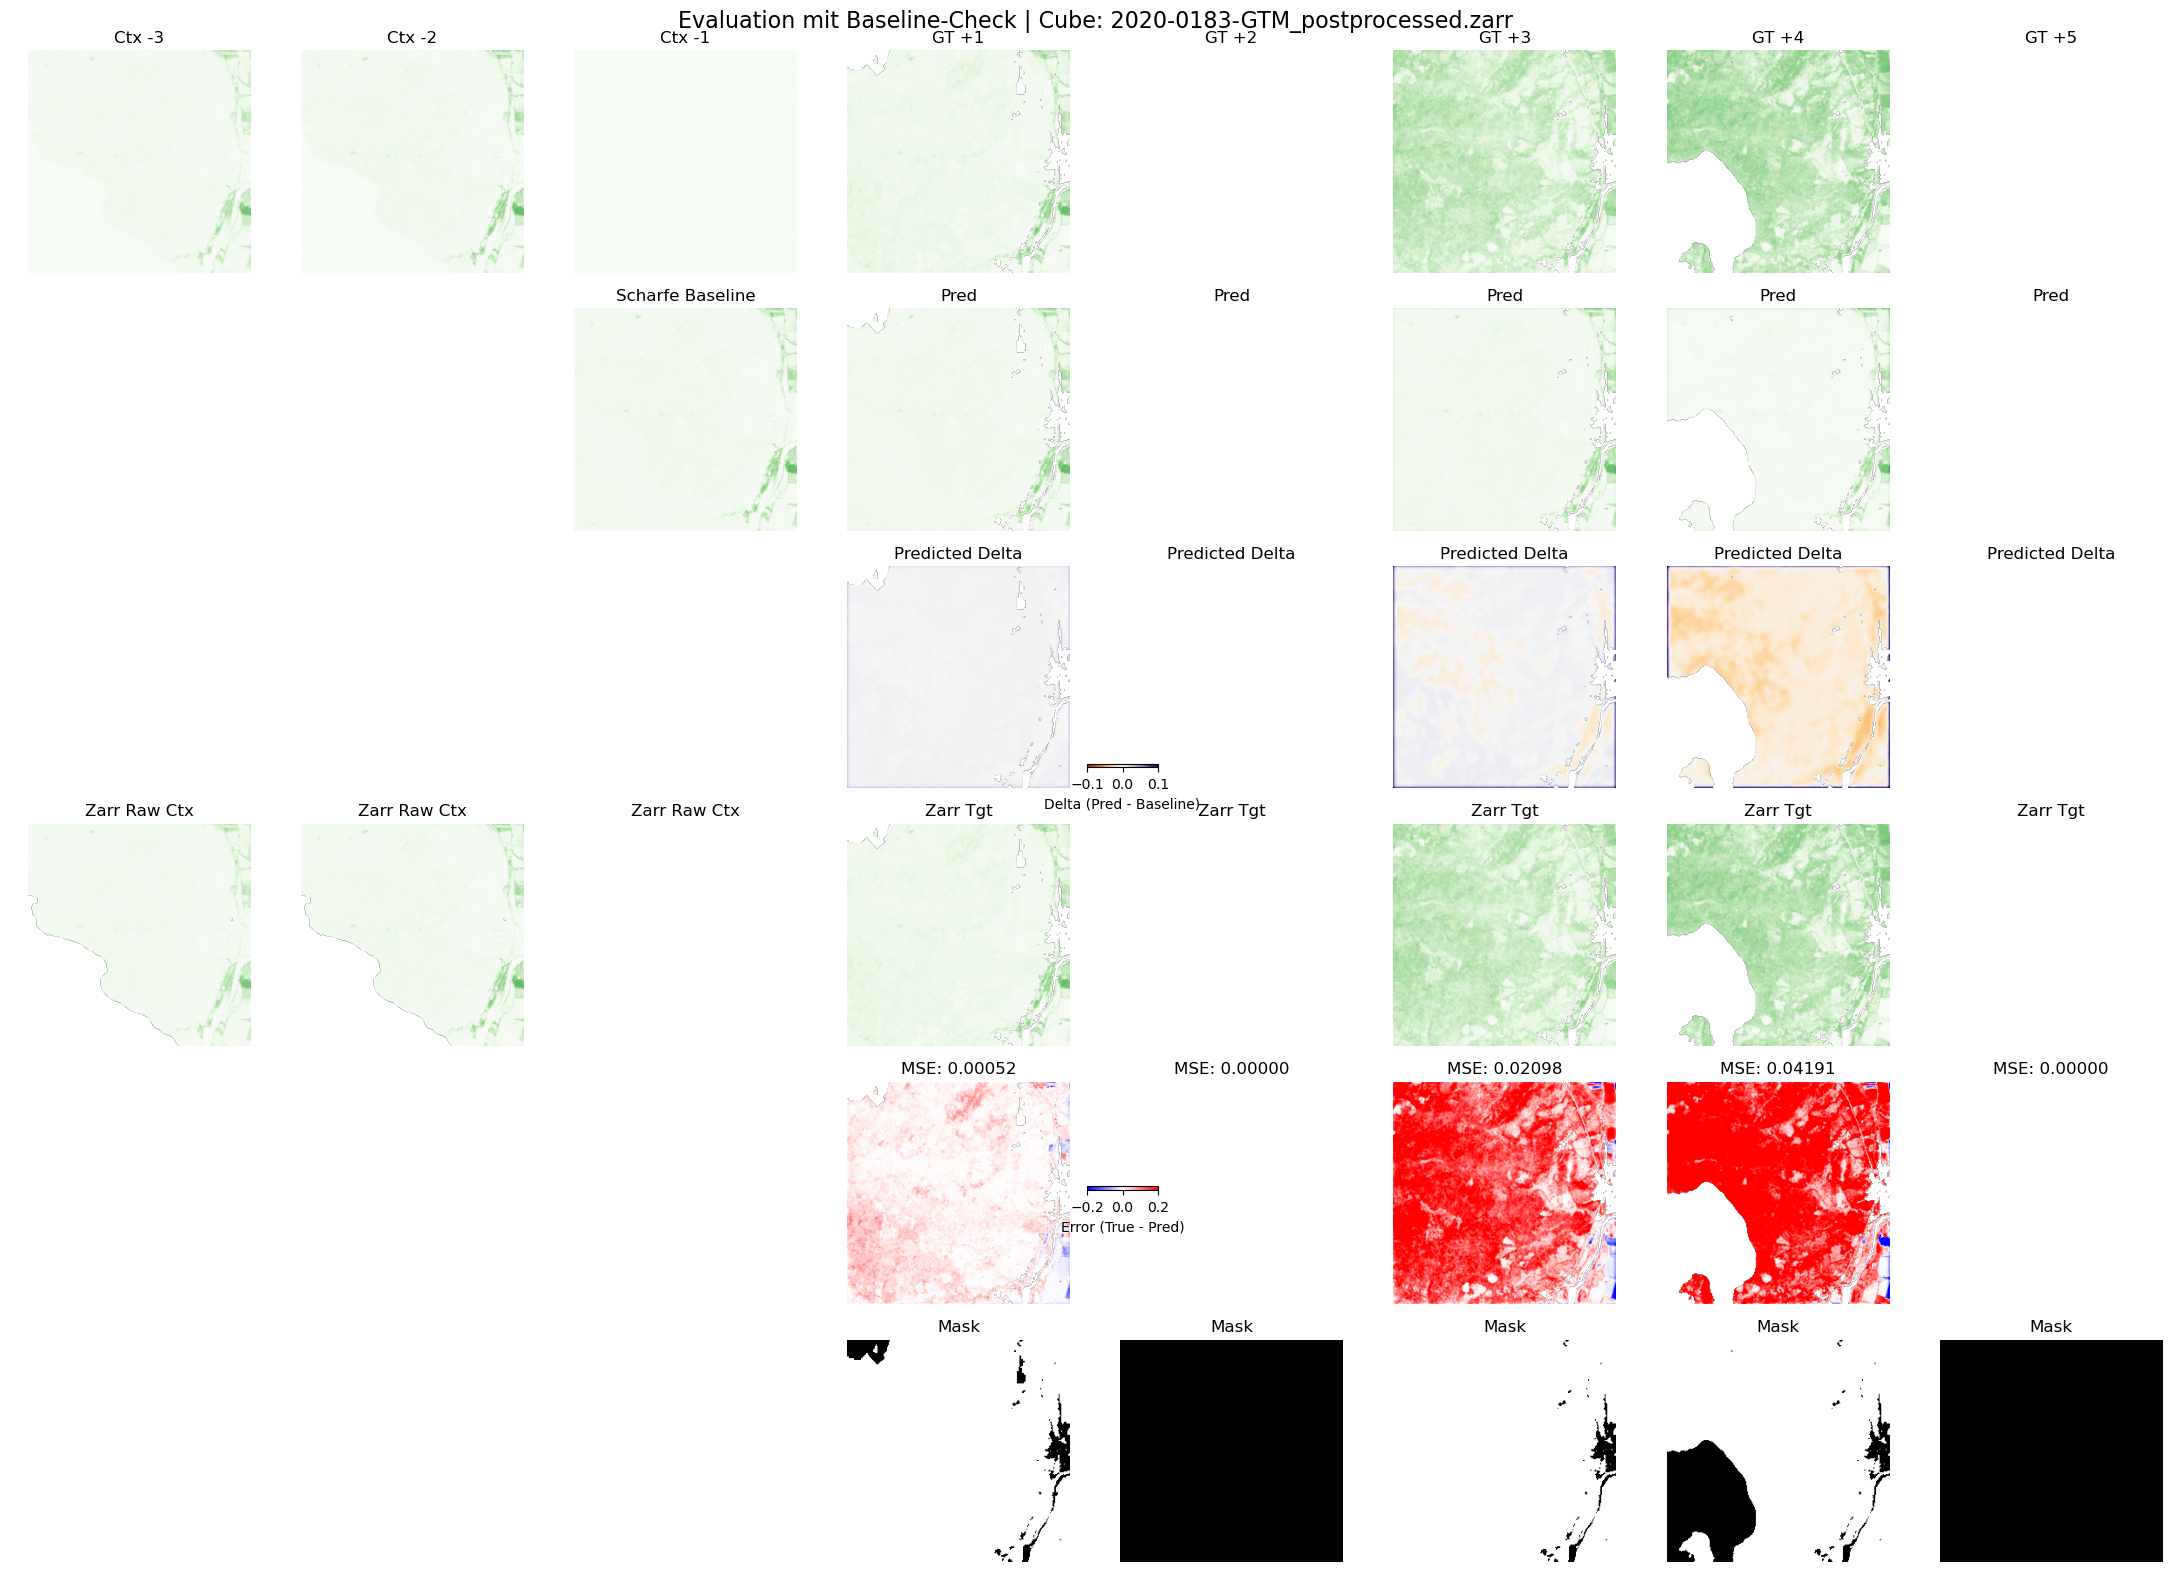

In [19]:
def run_full_evaluation(loader, model, test_files, patches_per_cube=4):
    model.eval()
    model.to(device)
    iter_loader = iter(loader)
    
    # Da der Loader alle Cubes nacheinander liefert, tracken wir den Fortschritt
    current_batch_idx = 0
    
    for cube_url in test_files:
        print("\n" + "="*50)
        print(f"🌍 EVALUIERE CUBE: {cube_url.split('/')[-1]}")
        print("="*50 + "\n")
        
        # 1. Open the zarr cube
        ds = xr.open_zarr(cube_url)
        cutoff_date = pd.to_datetime(ds.attrs["precip_end_date"])
        
        # Slice in context and target window
        ds_ctx_raw = ds.sel(time_sentinel_2_l2a=slice(None, cutoff_date)).tail(time_sentinel_2_l2a=context_length)
        ds_target_raw = ds.sel(time_sentinel_2_l2a=slice(cutoff_date + pd.Timedelta(days=1), None)).head(time_sentinel_2_l2a=target_length)

        cube_mse_history = []
        cube_pixel_counts = []
        
        # 2. Loop over the N batches of this cube
        for p in range(patches_per_cube):
            try:
                batch = next(iter_loader)
            except StopIteration:
                return

            x_ctx, x_fut, y_true, mask, meta, baseline = batch

            # All relevant variables to GPU (if available)
            x_ctx = x_ctx.to(device)
            x_fut = x_fut.to(device)
            baseline = baseline.to(device)
            
            # Prediction
            with torch.no_grad():
                y_pred, _, _ = model(x_ctx, prediction_count=target_length, non_pred_feat=x_fut, baseline_sample=baseline)
            
            # Data preparation
            # cpu is necessary to call numpy()
            ctx_np = x_ctx[0, :, 0].cpu().numpy()    
            true_np = y_true[0, :, 0].cpu().numpy()
            pred_np = y_pred[0, :, 0].cpu().numpy()
            mask_np = mask[0, :, 0].cpu().numpy()
            baseline_np = baseline[0, 0].cpu().numpy()
            
            # MSE berechnen
            mse_steps = []
            valid_pixels_steps = []

            print(f"--- 🧩 Patch {p+1}/{patches_per_cube} (y={int(meta['top'][0])}, x={int(meta['left'][0])}) ---")
            print(f"{'Step':<10} | {'MSE':<12} | {'Valid Pixels':<15} | {'% of Patch':<10}")
            print("-" * 55)

            for t in range(target_length):
                v_mask = mask_np[t] == 1
                num_valid = v_mask.sum()
                
                if num_valid > 0:
                    mse = np.mean((true_np[t][v_mask] - pred_np[t][v_mask])**2)
                else:
                    mse = 0.0
                
                mse_steps.append(mse)
                valid_pixels_steps.append(num_valid)
                
                pct = (num_valid / (patch_size**2)) * 100
                print(f"Timestep {t+1:<2} | {mse:<12.6f} | {num_valid:<15} | {pct:>6.1f}%")
            
            cube_mse_history.append(mse_steps)
            cube_pixel_counts.append(valid_pixels_steps)

            # Zarr Slicing für diesen Patch (KORREKTES Y/X MAPPING)
            y_m, x_m = int(meta['top'][0]), int(meta['left'][0])
            z_ctx = ds_ctx_raw.kNDVI.isel(y=slice(y_m, y_m+patch_size), x=slice(x_m, x_m+patch_size)).values
            z_tgt = ds_target_raw.kNDVI.isel(y=slice(y_m, y_m+patch_size), x=slice(x_m, x_m+patch_size)).values

            print(f"  [Patch {p+1}/{patches_per_cube}] Koordinaten: y={y_m}, x={x_m} | Avg MSE: {np.mean(mse_steps):.6f}")
            
            # Plotten
            # plot_patch_comparison(ctx_np, true_np, pred_np, mask_np, z_ctx, z_tgt, meta, mse_steps)
            plot_patch_comparison(ctx_np, true_np, pred_np, mask_np, z_ctx, z_tgt, meta, mse_steps, baseline_np)
            print("\n")
        
        # --- 3. Zusammenfassender Loss-Plot pro Cube ---
        if cube_mse_history:
            print("="*60)
            print(f"📊 OVERALL STATISTIK FÜR CUBE: {cube_url.split('/')[-1]}")
            
            # Gewichteter Durchschnitt (MSE * Pixel / Gesamtpixel pro Step)
            history_array = np.array(cube_mse_history)
            pixels_array = np.array(cube_pixel_counts)
            
            total_pixels_per_step = pixels_array.sum(axis=0)
            weighted_mse_per_step = (history_array * pixels_array).sum(axis=0) / (total_pixels_per_step + 1e-8)
            
            print(f"{'Overall Step':<15} | {'Weighted MSE':<15} | {'Total Valid Pixels':<18}")
            for t in range(target_length):
                print(f"Step {t+1:<10} | {weighted_mse_per_step[t]:<15.6f} | {int(total_pixels_per_step[t]):<18}")
            
            total_cube_mse = weighted_mse_per_step.mean()
            print("-" * 60)
            print(f"🏆 GESAMT-CUBE MSE: {total_cube_mse:.6f}")
            print("="*60 + "\n")

            # Zusammenfassender Plot
            plt.figure(figsize=(10, 5))
            plt.plot(range(1, target_length+1), weighted_mse_per_step, color='green', marker='s', linewidth=3, label='Weighted Avg MSE')
            plt.fill_between(range(1, target_length+1), weighted_mse_per_step, alpha=0.1, color='green')
            plt.title(f"Gewichteter MSE Verlauf - {cube_url.split('/')[-1]}")
            plt.ylabel("MSE")
            plt.xlabel("Timestep")
            plt.grid(True, alpha=0.2)
            plt.legend()
            plt.show()

        ds.close()

# --- START ---
iter_loader = iter(test_loader)
run_full_evaluation(test_loader, model, selected_files, patches_per_cube=PATCHES_PER_CUBE)

In [20]:
CSV_PATH = "../../data_processing/data/train_test_split.csv"
df = pd.read_csv(CSV_PATH)
df[df["DisNo."]=="2018-0103-BWA"][["pheno_season_name", "koppen_geiger" ]]

,pheno_season_name,koppen_geiger
30,Hotter,BSh


In [21]:
import torch
import numpy as np
import pandas as pd
from utils.losses import MaskedMSELoss

def calculate_permutation_importance(model, val_loader, device):
    model.eval()
    criterion = MaskedMSELoss()
    
    # 1. Baseline Statistiken berechnen
    baseline_losses = []
    persistence_losses = []
    prediction_variance = []

    print("--- Start Baseline Evaluation ---")
    with torch.no_grad():
        for x_ctx, x_fut, y, mask, meta, baseline_sample in val_loader:

            # Put on device
            x_ctx, x_fut, y, mask, baseline_sample = (
                x_ctx.to(device), x_fut.to(device), y.to(device), 
                mask.to(device), baseline_sample.to(device)
            )
            pixels_per_step = mask.sum(dim=(0, 2, 3, 4)) # Summe über Batch, Channel, H, W
            print(f"Sichtbare Pixel pro Timestep: {pixels_per_step}")
            
            preds, pred_deltas, baselines = model(x_ctx, 5, x_fut, baseline_sample)

            # A) Main loss between preds and true values
            loss = criterion(preds, y, mask)
            baseline_losses.append(loss.item())

            # B) How does baseline differ from truth
            loss_pers = criterion(baselines, y, mask)
            persistence_losses.append(loss_pers.item())

            # C) How strong does prediction differ from baseline (Model activity) 
            loss_activity = criterion(preds, baselines, mask)
            prediction_variance.append(loss_activity.item())

        avg_baseline_loss = np.mean(baseline_losses)
        avg_persistence = np.mean(persistence_losses)
        avg_activity = np.mean(prediction_variance)

        print(f"Global Baseline Loss (MSE): {avg_baseline_loss:.10f}")
        print(f"Persistence Loss (Baseline vs Target): {avg_persistence:.10f}")
        print(f"Model Delta Activity: {avg_activity:.10f}")

    if avg_activity < 1e-6:
        print("⚠️ Warnung: Das Modell sagt fast exakt die Baseline voraus. Features werden kaum Einfluss haben.")
        
    # --- 2. Permutation Importance ---
    # Liste deiner Features (Muss exakt der Reihenfolge im Input-Tensor entsprechen)
    # Beispiel: x_ctx hat Shape [B, T, C, H, W] -> C sind deine Features
    features = ["kNDVI", "IRECI", "NDWI", "NIRv", "vv", "vh", "t2m_mean", "t2mmax_max", "t2mmin_min", "tp_dailymean_mean", "tp_dailymax_max", "pei_30_mean", "pei_90_mean","mask_s2", "mask_s1", "LC_0", "LC_10", "LC_20", "LC_30", "LC_40", "LC_50", "LC_60", "LC_70", "LC_80", "LC_90", "LC_95", "LC_100", "COP_DEM", "is_veg"]
    print("No features", len(features))
    results = {}

    for i, feat_name in enumerate(features):
        permuted_losses = []
        with torch.no_grad():
            for x_ctx, x_fut, y, mask, meta, baseline_sample in val_loader:
                x_ctx_perm = x_ctx.clone().to(device)
                print(x_ctx.shape)
                # Permutiere das Feature i über die Batch-Dimension
                # Wir mischen die Proben (B) für diesen Kanal (i) durch
                perm_indices = torch.randperm(x_ctx.size(0), device=x_ctx.device)
                x_ctx_perm[:, :, i, :, :] = x_ctx_perm[perm_indices, :, i, :, :]
                
                preds_perm, pred_deltas, baselines = model(x_ctx_perm.to(device), 5, x_fut.to(device), baseline_sample.to(device))
                                
                loss_p = criterion(preds_perm, y.to(device), mask.to(device))
                permuted_losses.append(loss_p.item())
        
        # Absolute Wichtigkeit
        diff = np.mean(permuted_losses) - avg_baseline_loss
        # Relative Wichtigkeit (Prozentualer Anstieg des Fehlers)
        rel_diff = (diff / (avg_baseline_loss + 1e-12)) * 100

        results[feat_name] = diff
        print(f"Feature {feat_name:15} | Delta MSE: {diff:.10f} | Rel: {rel_diff:7.4f}%")

    return results

# Ausführung
importance_scores = calculate_permutation_importance(model, test_loader, "cuda")

--- Start Baseline Evaluation ---
Sichtbare Pixel pro Timestep: tensor([221261.,      0., 256860., 172428.,      0.], device='cuda:0')
Global Baseline Loss (MSE): 0.0148465233
Persistence Loss (Baseline vs Target): 0.0133247618
Model Delta Activity: 0.0000727452
No features 29
torch.Size([4, 40, 29, 256, 256])
Feature kNDVI           | Delta MSE: 0.0000163829 | Rel:  0.1103%
torch.Size([4, 40, 29, 256, 256])
Feature IRECI           | Delta MSE: 0.0000000000 | Rel:  0.0000%


KeyboardInterrupt: 

In [23]:
import matplotlib.pyplot as plt

def visualize_hidden_states(self, x_ctx, x_fut, baseline_sample):
        self.model.eval()
        with torch.no_grad():
            # Wir brauchen Zugriff auf die internen Layer deines ConvLSTM
            # Angenommen, dein ConvLSTM speichert die hidden states in einer Liste 
            # oder gibt sie am Ende des Encoders zurück.
            
            # Falls dein Modell die Hidden States nicht zurückgibt, nutze einen Hook:
            activations = {}
            def get_activation(name):
                def hook(model, input, output):
                    # output bei ConvLSTM ist oft (hidden_state, cell_state)
                    if isinstance(output, tuple):
                        activations[name] = output[0].detach()
                    else:
                        activations[name] = output.detach()
                return hook

            # Registriere den Hook am letzten Encoder-Layer (beispielhafter Name)
            handle = self.model.encoder.cell_list[-1].register_forward_hook(get_activation('last_hidden'))
            
            # Einmal durchlaufen lassen
            _ = self(x_ctx, 5, x_fut, baseline_sample)
            handle.remove()

            hidden = activations['last_hidden'] # Shape: (B, Hidden_Channels, H, W)
            
            # Visualisierung der ersten 8 Hidden Channels des ersten Batch-Samples
            fig, axes = plt.subplots(2, 4, figsize=(15, 8))
            for i in range(8):
                ax = axes[i//4, i%4]
                # Normalisiere für die Anzeige, um auch kleine Signale zu sehen
                h_img = hidden[0, i].cpu().numpy()
                im = ax.imshow(h_img, cmap='viridis')
                ax.set_title(f"Channel {i}\nMax: {h_img.max():.4f}")
                plt.colorbar(im, ax=ax)
            
            plt.tight_layout()
            plt.show()
            return fig

In [24]:
fig =  visualize_hidden_states(x_ctx, x_fut, baseline_sample)

NameError: name 'self' is not defined